In [1]:
import os
from pypdf import PdfReader
import json
import string
import random
import pandas as pd
import numpy as np
import torch
from collections import Counter
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Import data
lstm = PdfReader(r"C:\Users\USER\Downloads\LSTM.pdf")
ailyn = PdfReader(r"C:\Users\USER\Downloads\AILYN.pdf")

text = ""

for i in lstm.pages:
    text += i.extract_text() + "\n"

for j in ailyn.pages:
    text += j.extract_text() + "\n"

In [3]:
# Clean text
def clean_text(text):
    """
    This function aims to clean the text extracted
    """
    clean = str.maketrans('', '', string.punctuation)
    text = text.translate(clean)
    text = text.replace("\n", " ").lower().split()
    return text

text = clean_text(text)
print(text)

['department', 'of', 'computer', 'science', 'tdt4173', 'assignment', '1', 'time', 'series', 'long', 'shortterm', 'memory', 'rnn', 'group', 'group', '8', 'time', 'series', 'authors', 'adrian', 'kjærran', 'adriankj', 'erling', 'stray', 'bugge', 'erlinsb', 'christian', 'bakke', 'vennerød', 'christbv', 'may', '17', '2021', 'arxiv210506756v1', 'cslg', '14', 'may', '2021', 'abstract', 'this', 'paper', 'is', 'the', 'ﬁrst', 'assignment', 'in', 'the', 'course', 'machine', 'learning', 'tdt4173', 'fall', '2020', 'the', 'project', 'was', 'conducted', 'by', 'reading', 'through', 'some', 'of', 'the', 'latest', 'developments', 'within', 'timeseries', 'forecasting', 'methods', 'in', 'the', 'scientiﬁc', 'community', 'over', 'the', 'past', '5', 'years', 'the', 'result', 'is', 'a', 'summary', 'of', 'the', 'essential', 'aspects', 'in', 'this', 'paper', 'we', 'introduce', 'an', 'lstm', 'cell’s', 'architecture', 'and', 'explain', 'how', 'diﬀerent', 'com', 'ponents', 'go', 'together', 'to', 'alter', 'the', '

In [4]:
# Turn to and split

tokens = pd.Series(text)

split = int(0.8 * len(tokens))
train = tokens[:split]
test = tokens[split:]

In [5]:
# I need to transform train data to tokens then transform test from train
def tokenizer(train, test):
    """
    Create unique id from the train data,
    map it to the test data, and if there's
    any unique in the test, change it to 0
    """
    unique_tokens = list(dict.fromkeys(train))
    
    # IDs start from 1
    tokens_map = {word: idx + 1 for idx, word in enumerate(unique_tokens)}
    
    # Reserve 0 for unknown
    tokens_map["UKN"] = 0
    
    # Tokenize
    train_token = [tokens_map.get(tk, 0) for tk in train]
    test_token  = [tokens_map.get(tk, 0) for tk in test]
    
    return train_token, test_token, tokens_map


# Usage
train, test, word_to_id = tokenizer(train, test)

In [6]:
train

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 14,
 15,
 8,
 9,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 28,
 30,
 34,
 35,
 36,
 37,
 38,
 39,
 6,
 40,
 38,
 41,
 42,
 43,
 5,
 44,
 45,
 38,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 2,
 38,
 53,
 54,
 55,
 56,
 57,
 58,
 40,
 38,
 59,
 60,
 61,
 38,
 62,
 63,
 64,
 38,
 65,
 37,
 66,
 67,
 2,
 38,
 68,
 69,
 40,
 35,
 36,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 38,
 74,
 12,
 76,
 86,
 38,
 87,
 88,
 38,
 36,
 89,
 38,
 90,
 91,
 76,
 92,
 84,
 93,
 66,
 94,
 95,
 51,
 72,
 73,
 96,
 38,
 36,
 97,
 84,
 98,
 76,
 99,
 100,
 101,
 38,
 102,
 76,
 103,
 2,
 104,
 105,
 55,
 38,
 56,
 106,
 76,
 38,
 107,
 108,
 109,
 110,
 111,
 106,
 112,
 113,
 114,
 58,
 115,
 8,
 9,
 116,
 117,
 118,
 119,
 38,
 36,
 120,
 121,
 122,
 76,
 123,
 124,
 125,
 126,
 104,
 127,
 128,
 129,
 126,
 66,
 130,
 75,
 38,
 36,
 131,
 100,
 38,
 132,
 133,
 66,


In [7]:
# Save json
with open("tokenizer.json", "w", encoding="utf-8") as f:
    json.dump(word_to_id, f, indent=4, ensure_ascii=False)

In [8]:
# create window function and transform to array

def window(tokens, input_length, output_length):

    X_train = []
    y_train = []
    for i in range(len(tokens) - input_length - output_length + 1):
        X = tokens[i:input_length+i]
        y = tokens[i+input_length:i+input_length+output_length]
        
        X_train.append(X)
        y_train.append(y)

    return np.array(X_train, dtype=np.int32), np.array(y_train, dtype=np.int32).squeeze(-1)

In [9]:
X_train, y_train = window(train, 30, 1)
X_test, y_test = window(test, 30, 1)

In [10]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (9480, 30)
y_train shape: (9480,)


In [11]:
# lets convert it to tensor dataset

X_train_tensors = torch.tensor(X_train, dtype=torch.long)
y_train_tensors = torch.tensor(y_train, dtype=torch.long)

X_test_tensors = torch.tensor(X_test, dtype=torch.long)
y_test_tensors = torch.tensor(y_test, dtype=torch.long)

In [12]:
# Save to tensor
train_tensor = TensorDataset(X_train_tensors, y_train_tensors)
test_tensor = TensorDataset(X_test_tensors, y_test_tensors)

In [13]:
# Save to data loader
train_loader = DataLoader(train_tensor, batch_size=32, shuffle=False)
test_loader = DataLoader(test_tensor, batch_size=32, shuffle=False)

In [14]:
# Model Achitecture

class WordPred(nn.Module):
    def __init__(self, vocab_size, hidden_dim=64, embed_dim=64):
        super().__init__()

        # Lets use embaddings
        self.embed = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, vocab_size),
        )

    def forward(self, X):
        emb = self.embed(X)
        _, (h_n, _) = self.lstm(emb)

        return self.fc(h_n[-1])

In [15]:
model = WordPred(len(word_to_id))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [16]:
# Training function

def train(model, criterion, optimizer, train_loader, epochs):
    model.train()
    loss_plot = []
    for epoch in range(epochs):
        total_loss=0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss+=loss.item()
            loss.backward()
            optimizer.step()
        mean_loss = total_loss/len(train_loader)
        loss_plot.append(mean_loss)
        print(f" Epoch: {epoch+1}, Loss: {mean_loss:.2f}")

    plt.figure(figsize=(7, 5))
    plt.plot(loss_plot)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.savefig("Loss plot.png")
    plt.show()

 Epoch: 1, Loss: 6.93
 Epoch: 2, Loss: 6.34
 Epoch: 3, Loss: 6.22
 Epoch: 4, Loss: 6.04
 Epoch: 5, Loss: 5.90
 Epoch: 6, Loss: 5.80
 Epoch: 7, Loss: 5.66
 Epoch: 8, Loss: 5.56
 Epoch: 9, Loss: 5.47
 Epoch: 10, Loss: 5.39
 Epoch: 11, Loss: 5.29
 Epoch: 12, Loss: 5.18
 Epoch: 13, Loss: 5.13
 Epoch: 14, Loss: 5.02
 Epoch: 15, Loss: 4.88
 Epoch: 16, Loss: 4.76
 Epoch: 17, Loss: 4.89
 Epoch: 18, Loss: 4.69
 Epoch: 19, Loss: 4.49
 Epoch: 20, Loss: 4.39
 Epoch: 21, Loss: 4.30
 Epoch: 22, Loss: 4.21
 Epoch: 23, Loss: 4.43
 Epoch: 24, Loss: 4.29
 Epoch: 25, Loss: 4.16
 Epoch: 26, Loss: 4.08
 Epoch: 27, Loss: 3.99
 Epoch: 28, Loss: 3.88
 Epoch: 29, Loss: 3.79
 Epoch: 30, Loss: 3.70
 Epoch: 31, Loss: 3.61
 Epoch: 32, Loss: 3.54
 Epoch: 33, Loss: 3.43
 Epoch: 34, Loss: 3.37
 Epoch: 35, Loss: 3.28
 Epoch: 36, Loss: 3.20
 Epoch: 37, Loss: 3.13
 Epoch: 38, Loss: 3.05
 Epoch: 39, Loss: 2.99
 Epoch: 40, Loss: 2.91
 Epoch: 41, Loss: 2.85
 Epoch: 42, Loss: 2.75
 Epoch: 43, Loss: 2.76
 Epoch: 44, Loss: 2.

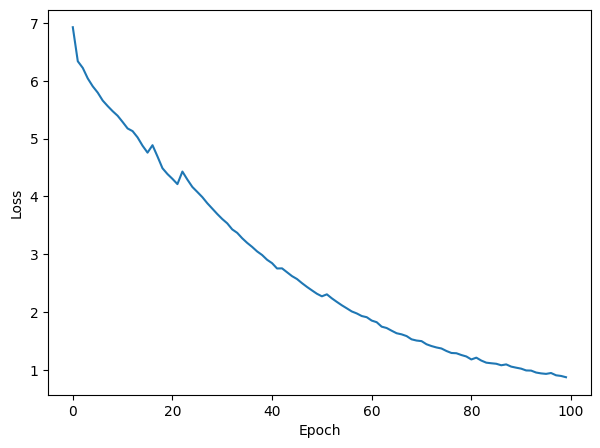

In [17]:
train(model, criterion, optimizer, train_loader, 100)

In [18]:
model.eval()
all_predictions = []
all_actual = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        predicted = y_pred.argmax(dim=1)
        
        all_predictions.append(predicted)
        all_actual.append(y_batch.squeeze())


predictions = torch.cat(all_predictions)
actual = torch.cat(all_actual)


correct = (predictions == actual).sum().item()
accuracy = correct / len(actual)

print(f"Testing Accuracy: {accuracy:.2%}")

Testing Accuracy: 4.68%


In [19]:
# Train Data

model.eval()
all_predictions = []
all_actual = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        predicted = y_pred.argmax(dim=1)
        
        all_predictions.append(predicted)
        all_actual.append(y_batch.squeeze())


predictions = torch.cat(all_predictions)
actual = torch.cat(all_actual)


correct = (predictions == actual).sum().item()
accuracy = correct / len(actual)

print(f"Training Accuracy: {accuracy:.2%}")

Training Accuracy: 87.84%


In [20]:
text = "Recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation [35, 2, 5]. Numerous efforts have since continued to push the boundaries of recurrent language models and encoder-decoder architectures"

def make_pred(text, word_to_id, model, max_new_words=1):
    model.eval()
    
    # Convert text to tokens
    words = text.lower().split()
    tokens = [word_to_id.get(w, 0) for w in words]
    
    # Create id: words
    id_to_word = {idx: word for word, idx in word_to_id.items()}
    
    seq_length = 30
    with torch.no_grad():
        for _ in range(max_new_words):
            # Take last sequence tokens or all if shorter than 30
            input_tokens = tokens[-seq_length:]
            input_tensor = torch.tensor([input_tokens], dtype=torch.long)
            
            # Predict
            output = model(input_tensor)
            next_token_id = output.argmax(dim=1).item()
            
            if next_token_id == 0:  # UKN
                break

            # Append predicted token to existing tokens
            tokens.append(next_token_id)
            # Append converted token to word to existing words
            words.append(id_to_word.get(next_token_id, "UKN"))
    
    return " ".join(words)


# Usage
result = make_pred(text, word_to_id, model, max_new_words=100)
print(result)

recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation [35, 2, 5]. numerous efforts have since continued to push the boundaries of recurrent language models and encoder-decoder architectures aidan n gomez∗ † university of toronto aidancstorontoedu łukasz kaiser ∗ google brain lukaszkaisergooglecom illia polosukhin∗ ‡ illiapolosukhingmailcom abstract the dominant sequence transduction models are based on 8 p100 our base model surpasses all previously published models and ensembles at a fraction of the training cost of any of the competitive models on the wmt 2014 english togerman translation task improving over the existing of queries d we will perform similarly of lstms were not implemented similarly in order of the decoder layer we used to the attention function in the case of

In [21]:
torch.save(model.state_dict(), "mini_lm.pt")